# AI & Machine Learning - Task 4
## Classification Models, Evaluation Metrics & Handling Imbalanced Data

### Objective

Build and evaluate a binary classification system using the Breast Cancer dataset.

### Models Used

- Logistic Regression
- Logistic Regression with class weighting
- Decision Tree Classifier

### Evaluation Metrics

- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1-Score
- ROC Curve
- ROC-AUC

### Key Learning Areas

- Binary classification
- Classification error analysis
- Precision vs Recall
- ROC-AUC
- Class imbalance
- Model comparison


## 1. Import Required Libraries

The following libraries are used for data manipulation, visualization, model training, preprocessing, and evaluation.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Dataset and preprocessing
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

## 2. Load the Dataset

The Breast Cancer Wisconsin dataset is available directly through scikit-learn.

The dataset contains numerical measurements of breast cancer tumors and a binary target indicating whether the tumor is malignant or benign.

In [3]:
# Load the dataset
data = load_breast_cancer()

# Create feature DataFrame
X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

# Target variable
y = pd.Series(
    data.target,
    name="target"
)

# Display dataset dimensions
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

Number of samples: 569
Number of features: 30


## 2.1 Explore the Dataset

Before training a model, we inspect the dataset structure, feature names, and target distribution.

In [4]:
# Display the first five rows
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# Display the feature names
X.columns.tolist()

['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension']

In [6]:
# Check the target distribution
y.value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [7]:
# Calculate class percentages
class_percentages = (
    y.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

class_percentages

target
0    37.26
1    62.74
Name: proportion, dtype: float64

## 3. Class Distribution

Before training the classification models, we examine the distribution of the two target classes.

A difference in class sizes can affect how a classification model learns. Therefore, it is important to understand the class distribution before evaluating model performance.

In [8]:
# Calculate the number of observations in each class
class_distribution = y.value_counts().sort_index()

# Display the class distribution
print("Class Distribution:")
print(class_distribution)

Class Distribution:
target
0    212
1    357
Name: count, dtype: int64


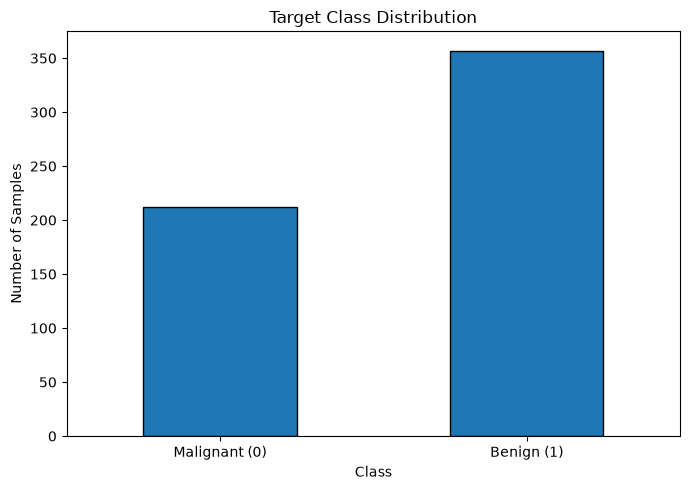

In [9]:
# Plot the class distribution
plt.figure(figsize=(7, 5))

class_distribution.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.xticks(
    ticks=[0, 1],
    labels=["Malignant (0)", "Benign (1)"],
    rotation=0
)

plt.tight_layout()
plt.show()

### Observation

The dataset contains more benign cases than malignant cases. Therefore, the two classes are not perfectly balanced.

Because of this difference, accuracy alone should not be used to judge the model. Metrics such as precision, recall, F1-score and ROC-AUC will also be considered.

## 4. Train-Test Split

The dataset is divided into training and testing sets.

- **80%** of the data is used for training the models.
- **20%** is reserved for testing model performance.

Stratification is used to preserve the original proportion of malignant and benign cases in both datasets.

A fixed `random_state` ensures that the split is reproducible.

In [10]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the resulting dataset sizes
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 455
Testing samples: 114


In [11]:
# Compare class distribution before and after the split
split_distribution = pd.DataFrame({
    "Full Dataset": y.value_counts(normalize=True),
    "Training Set": y_train.value_counts(normalize=True),
    "Testing Set": y_test.value_counts(normalize=True)
}) * 100

split_distribution.round(2)

,Full Dataset,Training Set,Testing Set
target,,,
1,62.74,62.64,63.16
0,37.26,37.36,36.84


## 5. Feature Scaling

The dataset contains numerical features with different ranges.

Standardization is applied so that the features are on a comparable scale. This is particularly useful for Logistic Regression.

To prevent data leakage, the scaler is fitted only on the training data and then used to transform both the training and testing data.

In [12]:
# Create the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [13]:
# Check the approximate mean and standard deviation
print("Training data mean:", X_train_scaled.mean().round(4))
print("Training data standard deviation:", X_train_scaled.std().round(4))

Training data mean: 0.0
Training data standard deviation: 1.0


## 6. Logistic Regression

Logistic Regression is used as the baseline classification model.

The model learns the relationship between the tumor measurements and the target class.

The trained model will then be used to predict the classes of the unseen test data.

In [14]:
# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000
)

# Train the model using the scaled training data
logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [15]:
# Predict the class labels for the test data
y_pred = logistic_model.predict(X_test_scaled)

# Display the first 10 predictions
y_pred[:10]

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0])

## 7. Classification Report

The classification report provides several metrics for evaluating the model:

- **Precision:** How reliable the model's positive predictions are.
- **Recall:** How many actual positive cases the model correctly identifies.
- **F1-Score:** A balance between precision and recall.
- **Support:** The number of actual observations belonging to each class.

These metrics provide more information than accuracy alone.

In [16]:
# Generate the classification report
print("Logistic Regression - Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Malignant", "Benign"]
    )
)

Logistic Regression - Classification Report
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 8. Confusion Matrix

A confusion matrix shows the relationship between the actual classes and the classes predicted by the model.

It contains four types of outcomes:

- **True Positive (TP):** The model correctly predicts the positive class.
- **True Negative (TN):** The model correctly predicts the negative class.
- **False Positive (FP):** The model predicts positive when the actual class is negative.
- **False Negative (FN):** The model predicts negative when the actual class is positive.

Looking at these errors helps us understand how the model is performing beyond its overall accuracy.

In [17]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[41  1]
 [ 1 71]]


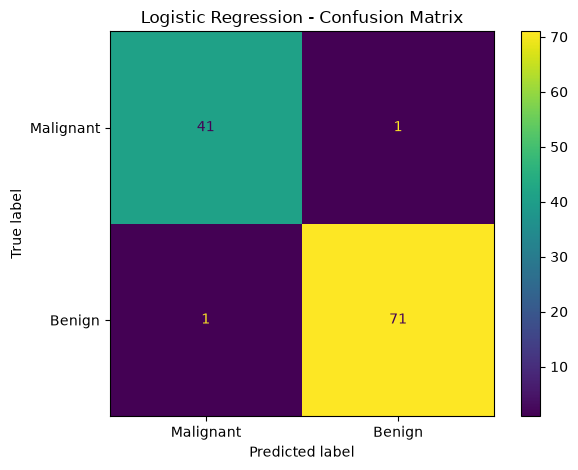

In [18]:
# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

## 9. Model Evaluation Metrics

We now calculate the main evaluation metrics individually so that their values can be compared directly.

In [19]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Store results in a DataFrame
metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics["Score"] = metrics["Score"].round(4)

metrics

,Metric,Score
0,Accuracy,0.9825
1,Precision,0.9861
2,Recall,0.9861
3,F1-Score,0.9861


In [20]:
# Evaluate malignant cases specifically
malignant_precision = precision_score(
    y_test,
    y_pred,
    pos_label=0
)

malignant_recall = recall_score(
    y_test,
    y_pred,
    pos_label=0
)

malignant_f1 = f1_score(
    y_test,
    y_pred,
    pos_label=0
)

print(f"Malignant Precision: {malignant_precision:.4f}")
print(f"Malignant Recall:    {malignant_recall:.4f}")
print(f"Malignant F1-Score:  {malignant_f1:.4f}")

Malignant Precision: 0.9762
Malignant Recall:    0.9762
Malignant F1-Score:  0.9762


## 10. ROC Curve and ROC-AUC

The ROC (Receiver Operating Characteristic) curve evaluates how well a classification model separates the two classes across different probability thresholds.

The AUC (Area Under the Curve) summarizes the model's ability to distinguish between the classes.

A higher AUC indicates better class discrimination.

In [21]:
# Generate probability predictions
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

# Calculate ROC-AUC
auc_score = roc_auc_score(
    y_test,
    y_prob
)

print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.9954


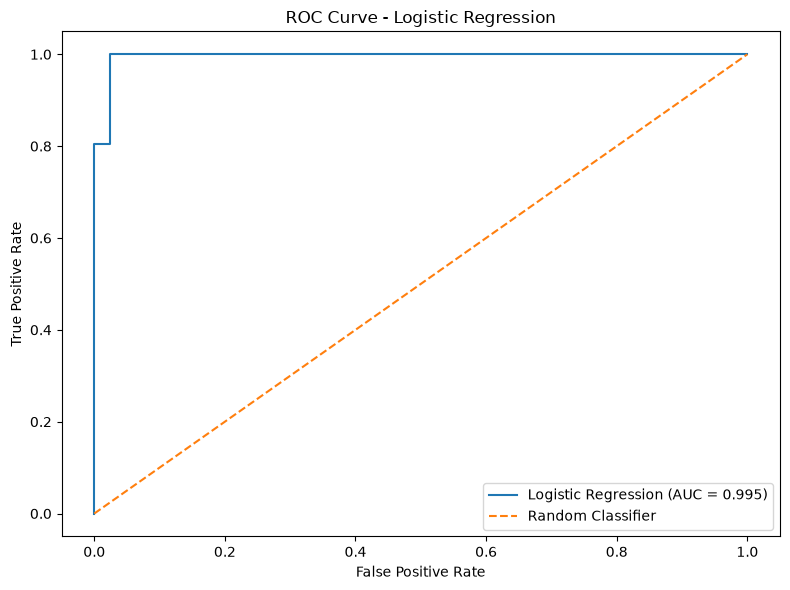

In [22]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.tight_layout()
plt.show()

## 11. Handling Class Imbalance

The dataset contains more benign cases than malignant cases.

To investigate whether accounting for this imbalance improves classification performance, we train a second Logistic Regression model using:

`class_weight="balanced"`

This automatically adjusts the class weights based on their frequencies in the training data.

In [23]:
# Create a class-weighted Logistic Regression model
balanced_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

# Train the model
balanced_model.fit(
    X_train_scaled,
    y_train
)

print("Balanced Logistic Regression model trained successfully.")

Balanced Logistic Regression model trained successfully.


In [24]:
# Generate predictions
y_pred_balanced = balanced_model.predict(X_test_scaled)

# Generate probability predictions
y_prob_balanced = balanced_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [25]:
print("Balanced Logistic Regression - Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_balanced,
        target_names=["Malignant", "Benign"]
    )
)

Balanced Logistic Regression - Classification Report
              precision    recall  f1-score   support

   Malignant       0.91      0.98      0.94        42
      Benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [26]:
balanced_malignant_precision = precision_score(
    y_test,
    y_pred_balanced,
    pos_label=0
)

balanced_malignant_recall = recall_score(
    y_test,
    y_pred_balanced,
    pos_label=0
)

balanced_malignant_f1 = f1_score(
    y_test,
    y_pred_balanced,
    pos_label=0
)

print(f"Malignant Precision: {balanced_malignant_precision:.4f}")
print(f"Malignant Recall:    {balanced_malignant_recall:.4f}")
print(f"Malignant F1-Score:  {balanced_malignant_f1:.4f}")

Malignant Precision: 0.9111
Malignant Recall:    0.9762
Malignant F1-Score:  0.9425


In [27]:
balanced_auc = roc_auc_score(
    y_test,
    y_prob_balanced
)

print(f"Balanced Logistic Regression ROC-AUC: {balanced_auc:.4f}")

Balanced Logistic Regression ROC-AUC: 0.9954


### Interpretation of Class Weighting

The balanced Logistic Regression model achieved a malignant recall of 97.62%, which is the same as the baseline Logistic Regression model.

However, malignant precision decreased from 97.62% to 91.11%, resulting in a lower F1-score of 94.25%.

This indicates that applying class weighting did not improve malignant recall on this test split. Instead, it caused the model to identify more cases as malignant, increasing false-positive predictions.

Therefore, class weighting should not automatically be considered an improvement. The effect of class weighting should be evaluated using the metrics that are most relevant to the application.

## 12. Decision Tree Classifier

A Decision Tree is a classification algorithm that makes decisions by repeatedly splitting the data based on feature values.

Unlike Logistic Regression, a Decision Tree can capture non-linear relationships between features.

Feature scaling is not required for Decision Trees, so the original training and testing features are used.

In [28]:
# Create the Decision Tree model
tree_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
tree_model.fit(
    X_train,
    y_train
)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [29]:
# Generate predictions
y_pred_tree = tree_model.predict(X_test)

# Generate probability predictions
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree predictions generated successfully.")

Decision Tree predictions generated successfully.


In [30]:
print("Decision Tree - Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=["Malignant", "Benign"]
    )
)

Decision Tree - Classification Report
              precision    recall  f1-score   support

   Malignant       0.85      0.93      0.89        42
      Benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



In [31]:
tree_malignant_precision = precision_score(
    y_test,
    y_pred_tree,
    pos_label=0
)

tree_malignant_recall = recall_score(
    y_test,
    y_pred_tree,
    pos_label=0
)

tree_malignant_f1 = f1_score(
    y_test,
    y_pred_tree,
    pos_label=0
)

tree_auc = roc_auc_score(
    y_test,
    y_prob_tree
)

print(f"Malignant Precision: {tree_malignant_precision:.4f}")
print(f"Malignant Recall:    {tree_malignant_recall:.4f}")
print(f"Malignant F1-Score:  {tree_malignant_f1:.4f}")
print(f"ROC-AUC:             {tree_auc:.4f}")

Malignant Precision: 0.8478
Malignant Recall:    0.9286
Malignant F1-Score:  0.8864
ROC-AUC:             0.9157


## 13. Final Model Comparison

The three classification models are compared using malignant-class precision, recall, F1-score and ROC-AUC.

The comparison helps determine which model provides the most suitable performance for this classification problem.

In [32]:
# Create final model comparison table

final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree"
    ],
    "Malignant Precision": [
        malignant_precision,
        balanced_malignant_precision,
        tree_malignant_precision
    ],
    "Malignant Recall": [
        malignant_recall,
        balanced_malignant_recall,
        tree_malignant_recall
    ],
    "Malignant F1-Score": [
        malignant_f1,
        balanced_malignant_f1,
        tree_malignant_f1
    ],
    "ROC-AUC": [
        auc_score,
        balanced_auc,
        tree_auc
    ]
})

final_comparison.round(4)

,Model,Malignant Precision,Malignant Recall,Malignant F1-Score,ROC-AUC
0,Logistic Regression,0.9762,0.9762,0.9762,0.9954
1,Balanced Logistic Regression,0.9111,0.9762,0.9425,0.9954
2,Decision Tree,0.8478,0.9286,0.8864,0.9157


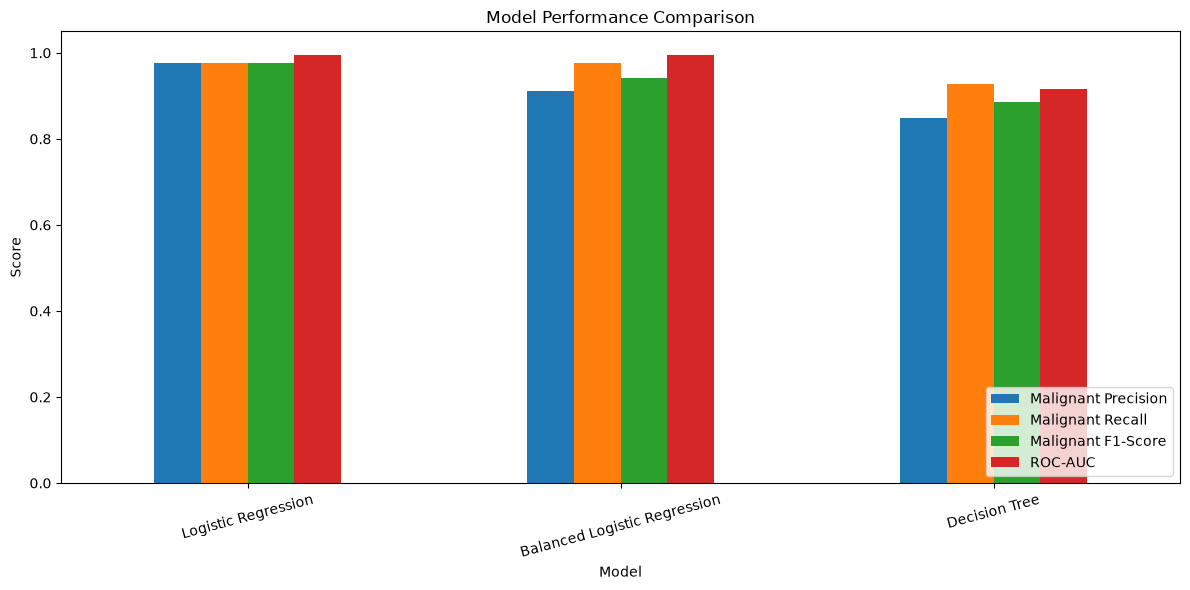

In [33]:
# Visualize model performance

final_comparison.set_index("Model").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

## 14. Conclusion

This project demonstrated a complete binary classification workflow using the Breast Cancer dataset.

Three models were evaluated:

1. Logistic Regression
2. Balanced Logistic Regression
3. Decision Tree

The models were evaluated using malignant-class precision, recall, F1-score and ROC-AUC.

The baseline Logistic Regression achieved strong performance, with malignant precision, recall and F1-score of approximately 97.62%.

The balanced Logistic Regression achieved the same malignant recall of 97.62%, but its malignant precision decreased to 91.11%. Therefore, class weighting did not improve malignant recall on this test split.

The Decision Tree performed worse than both Logistic Regression models, with malignant recall of 92.86%, F1-score of 88.64% and ROC-AUC of 91.57%.

Based on the results from this experiment, Logistic Regression provides the strongest overall performance for the chosen classification threshold, particularly because it achieves a strong balance between malignant precision and recall.

For a medical classification problem, recall is particularly important because false negatives represent actual malignant cases that are incorrectly predicted as benign. However, precision and F1-score should also be considered when selecting the final model.

Overall, this experiment demonstrates why classification models should be evaluated using multiple metrics rather than accuracy alone.

## 15. ROC Curve Comparison

The ROC curves of the three classification models are compared to evaluate their ability to distinguish between the two classes across different classification thresholds.

The Area Under the Curve (AUC) provides a single summary of the model's discrimination performance.

A curve closer to the top-left corner generally indicates better classification performance.

In [34]:
# Calculate ROC curves for all three models

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob
)

# Balanced Logistic Regression
fpr_balanced, tpr_balanced, _ = roc_curve(
    y_test,
    y_prob_balanced
)

# Decision Tree
fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    y_prob_tree
)

# Calculate AUC scores
auc_lr = roc_auc_score(y_test, y_prob)
auc_balanced = roc_auc_score(y_test, y_prob_balanced)
auc_tree = roc_auc_score(y_test, y_prob_tree)

print(f"Logistic Regression AUC:          {auc_lr:.4f}")
print(f"Balanced Logistic Regression AUC: {auc_balanced:.4f}")
print(f"Decision Tree AUC:                {auc_tree:.4f}")

Logistic Regression AUC:          0.9954
Balanced Logistic Regression AUC: 0.9954
Decision Tree AUC:                0.9157


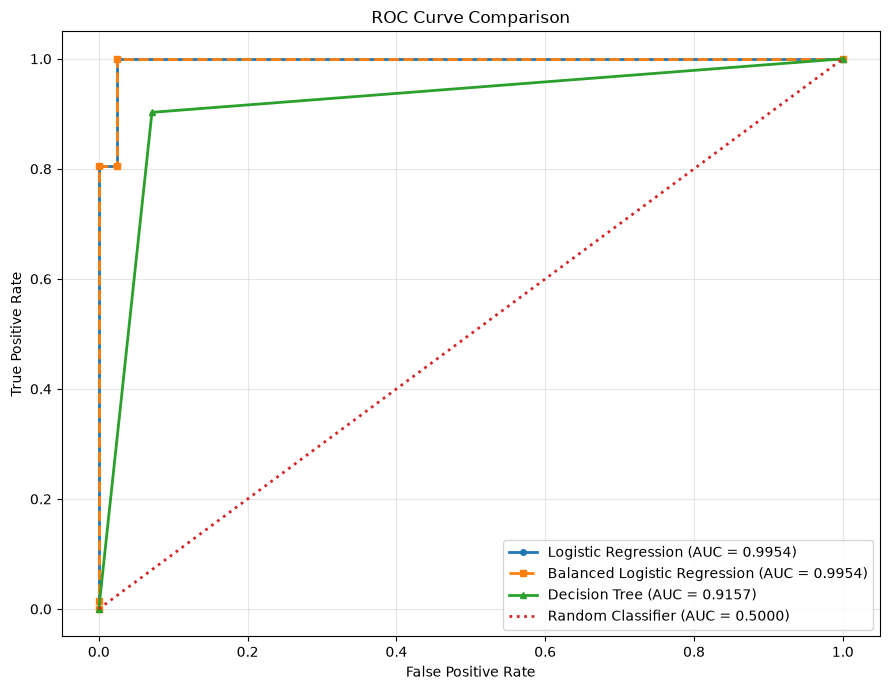

In [36]:
# Plot ROC curves for model comparison

plt.figure(figsize=(9, 7))

# Logistic Regression
plt.plot(
    fpr_lr,
    tpr_lr,
    linewidth=2,
    marker="o",
    markersize=4,
    label=f"Logistic Regression (AUC = {auc_lr:.4f})"
)

# Balanced Logistic Regression
plt.plot(
    fpr_balanced,
    tpr_balanced,
    linewidth=2,
    linestyle="--",
    marker="s",
    markersize=4,
    label=f"Balanced Logistic Regression (AUC = {auc_balanced:.4f})"
)

# Decision Tree
plt.plot(
    fpr_tree,
    tpr_tree,
    linewidth=2,
    marker="^",
    markersize=4,
    label=f"Decision Tree (AUC = {auc_tree:.4f})"
)

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    linewidth=2,
    label="Random Classifier (AUC = 0.5000)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### ROC Curve Observation

The Logistic Regression and Balanced Logistic Regression models have very similar ROC curves and nearly identical AUC values, indicating comparable overall class-discrimination ability across thresholds.

However, their precision and recall at the default classification threshold differ. This demonstrates that ROC-AUC and threshold-based metrics provide different perspectives on model performance.

The Decision Tree has a lower ROC-AUC of approximately 0.916, indicating weaker class discrimination compared with the Logistic Regression models.

## 16. Final Model Comparison

The three models are compared using accuracy, malignant-class precision, malignant-class recall, malignant-class F1-score, and ROC-AUC.

Because this is a medical classification problem, particular attention is given to malignant recall, since false negatives represent malignant cases incorrectly classified as benign.

In [37]:
# Calculate accuracy for each model
accuracy_lr = accuracy_score(y_test, y_pred)
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
accuracy_tree = accuracy_score(y_test, y_pred_tree)

# Create final comparison table
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_balanced,
        accuracy_tree
    ],
    "Malignant Precision": [
        malignant_precision,
        balanced_malignant_precision,
        tree_malignant_precision
    ],
    "Malignant Recall": [
        malignant_recall,
        balanced_malignant_recall,
        tree_malignant_recall
    ],
    "Malignant F1-Score": [
        malignant_f1,
        balanced_malignant_f1,
        tree_malignant_f1
    ],
    "ROC-AUC": [
        auc_lr,
        auc_balanced,
        auc_tree
    ]
})

# Format scores
final_comparison.round(4)

,Model,Accuracy,Malignant Precision,Malignant Recall,Malignant F1-Score,ROC-AUC
0,Logistic Regression,0.9825,0.9762,0.9762,0.9762,0.9954
1,Balanced Logistic Regression,0.9561,0.9111,0.9762,0.9425,0.9954
2,Decision Tree,0.9123,0.8478,0.9286,0.8864,0.9157


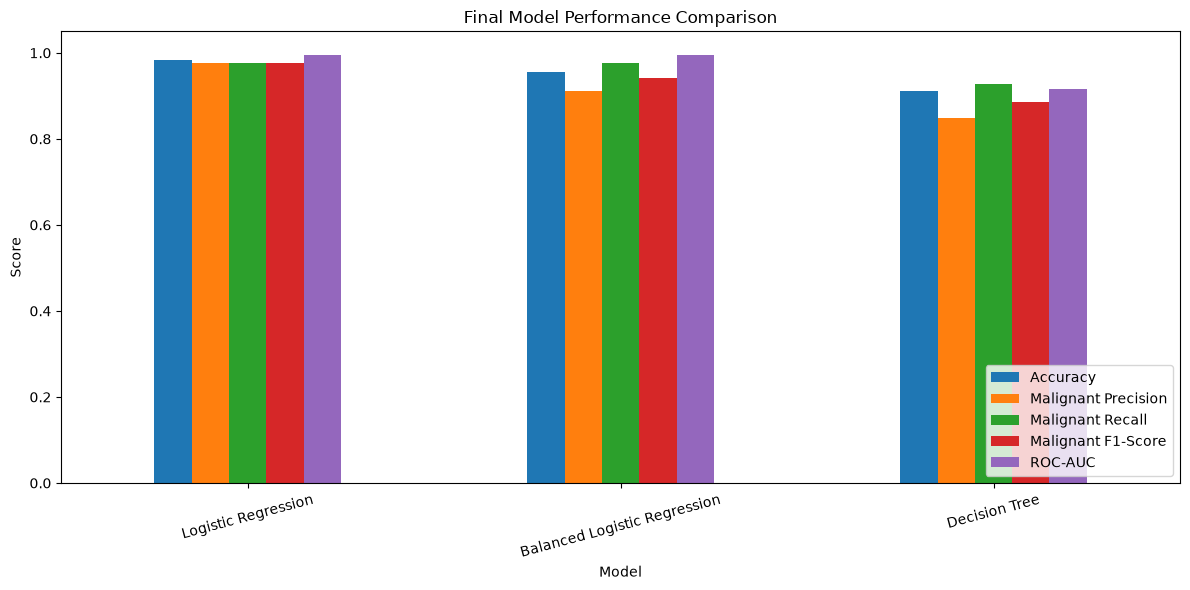

In [38]:
# Visual comparison of model performance

final_comparison.set_index("Model").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Final Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

## 17. Final Conclusion

This project investigated binary classification using the Breast Cancer dataset.

Three classification approaches were evaluated:

1. Logistic Regression
2. Balanced Logistic Regression
3. Decision Tree

The models were evaluated using accuracy, malignant-class precision, recall, F1-score, and ROC-AUC.

The baseline Logistic Regression model achieved strong performance, including a malignant precision of 97.62%, malignant recall of 97.62%, and malignant F1-score of 97.62%.

The Balanced Logistic Regression model maintained the same malignant recall of 97.62%, but its malignant precision decreased to 91.11%. This shows that applying class weighting did not automatically improve the model's performance for this particular test split.

The Decision Tree achieved a malignant recall of 92.86% and a malignant F1-score of 88.64%, which was lower than both Logistic Regression approaches.

The ROC-AUC comparison also showed very strong class discrimination for the Logistic Regression models, while the Decision Tree achieved a lower ROC-AUC.

Based on the combination of malignant precision, recall, F1-score, accuracy, and ROC-AUC, the baseline Logistic Regression model provides the strongest overall performance at the selected classification threshold for this experiment.

An important lesson from this project is that model selection should not be based on accuracy alone. In medical classification, recall and false negatives are particularly important because incorrectly classifying a malignant case as benign can have serious consequences.